In [1]:
from edgar import Company, set_identity

In [2]:
set_identity("Rahul kulkarni 99rahulkulkarni@gmail.com")

In [3]:
jpm = Company("JPM")
print(jpm)

Company(CIK=19617)


In [4]:
fillings = jpm.get_filings(form="10-K").latest(1)
fillings

╭─────────────── Form 10-K JPMORGAN CHASE & CO [19617]  ────────────────╮
│                                                                       │
│   Accession Number       Filing Date   Period of Report   Documents   │
│  ───────────────────────────────────────────────────────────────────  │
│   0001628280-26-008131   2026-02-13    2025-12-31         269         │
│                                                                       │
╰── Annual report for public companies • filing.docs for usage guide ───╯

![alt text](image.png)

In [5]:
fillings = jpm.get_filings(form="10-K").latest(1)
financials = fillings.obj().financials
financials.income_statement()

                                                                                                           
                                     JPMORGAN CHASE & CO   VYLD                                            
                                     CONSOLIDATED STATEMENT OF INCOME                                      
                                     Dec 31, 2023 to Dec 31, 2025                                          
                                                                                                           
                                                             Dec 31, 2025   Dec 31, 2024   Dec 31, 2023    
   ─────────────────────────────────────────────────────────────────────────────────────────────────────   
    STATEMENTS OF INCOME AND COMPREHENSIVE INCOME                                                          
    Revenue                                                                                                
        Investment banking f

In [6]:
financials.balance_sheet()


                                                                                                                   
                                           JPMORGAN CHASE & CO   VYLD                                              
                                           CONSOLIDATED BALANCE SHEETS                                             
                                           Dec 31, 2024 to Dec 31, 2025                                            
                                                                                                                   
                                                                                    Dec 31, 2025   Dec 31, 2024    
   ─────────────────────────────────────────────────────────────────────────────────────────────────────────────   
    BALANCE SHEETS                                                                                                 
        Assets                                                          

In [7]:
tickers = ["JPM", "GS", "MS"]
companies = {}

for ticker in tickers:
    company = Company(ticker)
    filing = company.get_filings(form="10-K").latest(1)
    financials = filing.obj().financials
    companies[ticker] = {
        "income_statement": financials.income_statement(),
        "balance_sheet": financials.balance_sheet(),
    }
    print(f"{ticker} pulled successfully")

JPM pulled successfully
GS pulled successfully
MS pulled successfully


In [8]:
for ticker in tickers:
    print(f"===== {ticker} — Income Statement =====")
    print(companies[ticker]["income_statement"])
    print()
    print(f"===== {ticker} — Balance Sheet =====")
    print(companies[ticker]["balance_sheet"])
    print()
    print("=" * 160)
    print()


===== JPM — Income Statement =====


                                                                                                           
                                     JPMORGAN CHASE & CO   VYLD                                            
                                     CONSOLIDATED STATEMENT OF INCOME                                      
                                     Dec 31, 2023 to Dec 31, 2025                                          
                                                                                                           
                                                             Dec 31, 2025   Dec 31, 2024   Dec 31, 2023    
   ─────────────────────────────────────────────────────────────────────────────────────────────────────   
    STATEMENTS OF INCOME AND COMPREHENSIVE INCOME                                                          
    Revenue                                                                                                
        Investment banking f

                                                                                                                                                      
                                                             JPMORGAN CHASE & CO   VYLD                                                               
                                                             CONSOLIDATED BALANCE SHEETS                                                              
                                                             Dec 31, 2024 to Dec 31, 2025                                                             
                                                                                                                                                      
                                                                                                                       Dec 31, 2025   Dec 31, 2024    
   ───────────────────────────────────────────────────────────────────────────────────────────

                                                                                                      
                               THE GOLDMAN SACHS GROUP, INC.   GS/31X                                 
                               CONSOLIDATED STATEMENT OF INCOME                                       
                               Dec 31, 2023 to Dec 31, 2025                                           
                                                                                                      
                                                        Dec 31, 2025   Dec 31, 2024   Dec 31, 2023    
   ────────────────────────────────────────────────────────────────────────────────────────────────   
    Revenues                                                                                          
        Investment banking                                    $9,348         $7,738         $6,218    
        Investment management                                $11,749     

                                                                                                                                                      
                                                       THE GOLDMAN SACHS GROUP, INC.   GS/31X                                                         
                                                       CONSOLIDATED BALANCE SHEETS                                                                    
                                                       Dec 31, 2024 to Dec 31, 2025                                                                   
                                                                                                                                                      
                                                                                                                       Dec 31, 2025   Dec 31, 2024    
   ───────────────────────────────────────────────────────────────────────────────────────────

                                                                                                                   
                                         MORGAN STANLEY   MS/29                                                    
                                         CONSOLIDATED STATEMENT OF INCOME                                          
                                         Dec 31, 2023 to Dec 31, 2025                                              
                                                                                                                   
                                                                     Dec 31, 2025   Dec 31, 2024   Dec 31, 2023    
   ─────────────────────────────────────────────────────────────────────────────────────────────────────────────   
    Revenues                                                                                                       
        Investment banking:                                             

                                                                                                                                        
                                                      MORGAN STANLEY   MS/29                                                            
                                                      CONSOLIDATED BALANCE SHEETS                                                       
                                                      Dec 31, 2024 to Dec 31, 2025                                                      
                                                                                                                                        
                                                                                                         Dec 31, 2025   Dec 31, 2024    
   ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────   
    Assets                               

Profitability ratios

In [9]:
df = companies["JPM"]["income_statement"].to_dataframe()


In [10]:
net_income_2023 = df[df["label"].str.contains("Net income", case=False, na=False)]
net_income_2023 = net_income_2023[net_income_2023["label"] == "Net income"][
    "2023-12-31 (FY)"
].values[0]
print(net_income_2023)


49552000000.0


In [11]:
def get_value(df, label_text):
    row = df[df["label"] == label_text]
    return {
        "2025": row["2025-12-31 (FY)"].values[0],
        "2024": row["2024-12-31 (FY)"].values[0],
        "2023": row["2023-12-31 (FY)"].values[0],
    }

In [12]:
jpm_income_df = companies["JPM"]["income_statement"].to_dataframe()
net_income = get_value(jpm_income_df, "Net income")
print(net_income)


{'2025': 57048000000.0, '2024': 58471000000.0, '2023': 49552000000.0}


In [13]:
jpm_balance_df = companies["JPM"]["balance_sheet"].to_dataframe()
print(
    jpm_balance_df[
        jpm_balance_df["label"].str.contains("total assets", case=False, na=False)
    ][["label"]]
)
print(
    jpm_balance_df[
        jpm_balance_df["label"].str.contains("total stockholders", case=False, na=False)
    ][["label"]]
)

            label
124  Total assets
                          label
219  Total stockholders’ equity


In [14]:
def get_value(df, label_text):
    row = df[df["label"].str.contains(label_text, case=False, na=False, regex=False)]
    year_columns = [col for col in df.columns if col[:4].isdigit()]
    result = {}
    for col in year_columns:
        year = col[:4]
        result[year] = row[col].values[0]
    return result


In [15]:
net_income = get_value(jpm_income_df, "Net income")
total_assets = get_value(jpm_balance_df, "Total assets")
total_equity = get_value(jpm_balance_df, "Total stockholders")
net_interest_income = get_value(jpm_income_df, "Net interest income")
print(net_interest_income)

print(net_income)
print(total_assets)
print(total_equity)


{'2025': 95443000000.0, '2024': 92583000000.0, '2023': 89267000000.0}
{'2025': 57048000000.0, '2024': 58471000000.0, '2023': 49552000000.0}
{'2025': 4424900000000.0, '2024': 4002814000000.0}
{'2025': 362438000000.0, '2024': 344758000000.0}


In [16]:
roe_2024 = net_income["2024"] / total_equity["2024"]
roa_2024 = net_income["2024"] / total_assets["2024"]
nim_2024 = net_interest_income["2024"] / total_assets["2024"]

roe_2025 = net_income["2025"] / total_equity["2025"]
roa_2025 = net_income["2025"] / total_assets["2025"]
nim_2025 = net_interest_income["2025"] / total_assets["2025"]

print("2024 — ROE:", roe_2024, "ROA:", roa_2024, "NIM:", nim_2024)
print("2025 — ROE:", roe_2025, "ROA:", roa_2025, "NIM:", nim_2025)


2024 — ROE: 0.16960012530528662 ROA: 0.014607473642292647 NIM: 0.0231294784119372
2025 — ROE: 0.1574007140531622 ROA: 0.01289249474564397 NIM: 0.02156952699496034


In [17]:
def get_value_flexible(df, possible_labels):
    for label in possible_labels:
        row = df[df["label"].str.contains(label, case=False, na=False, regex=False)]
        if len(row) > 0:  # found a match, stop searching
            year_columns = [col for col in df.columns if col[:4].isdigit()]
            result = {}
            for col in year_columns:
                year = col[:4]
                result[year] = row[col].values[0]
            return result
    return None  # no match found across any of the labels tried


In [18]:
gs_balance_df = companies["GS"]["balance_sheet"].to_dataframe()
ms_balance_df = companies["MS"]["balance_sheet"].to_dataframe()
ms_income_df = companies["MS"]["income_statement"].to_dataframe()

print("GS equity-related labels:")
print(
    gs_balance_df[gs_balance_df["label"].str.contains("equity", case=False, na=False)][
        ["label"]
    ]
)

print()
print("MS equity-related labels:")
print(
    ms_balance_df[ms_balance_df["label"].str.contains("equity", case=False, na=False)][
        ["label"]
    ]
)

print()
print("MS interest-related labels:")
print(
    ms_income_df[ms_income_df["label"].str.contains("interest", case=False, na=False)][
        ["label"]
    ]
)


GS equity-related labels:
                                          label
55         Liabilities and shareholders’ equity
104                        Shareholders’ equity
120                  Total shareholders’ equity
134  Total liabilities and shareholders’ equity

MS equity-related labels:
                                                 label
72   Debt and Equity Interests - Variable Interest ...
81   Debt and equity interests - Other - Variable I...
147                                             Equity
177          Total Morgan Stanley shareholders’ equity
180                                       Total equity
197                       Total liabilities and equity

MS interest-related labels:
                                                 label
13                                      Interest rates
39                         Total non-interest revenues
45                                     Interest income
51                                    Interest expense
57                

In [19]:
results = []

for ticker in tickers:
    income_df = companies[ticker]["income_statement"].to_dataframe()
    balance_df = companies[ticker]["balance_sheet"].to_dataframe()

    net_income = get_value_flexible(income_df, ["Net income", "Net earnings"])
    net_interest_income = get_value_flexible(
        income_df, ["Net interest income", "Net interest"]
    )
    total_assets = get_value_flexible(balance_df, ["Total assets"])
    total_equity = get_value_flexible(
        balance_df,
        [
            "Total stockholders",
            "Total shareholders",
            "Total Morgan Stanley shareholders",
        ],
    )

    print(ticker, "net_income:", net_income is not None)
    print(ticker, "net_interest_income:", net_interest_income is not None)
    print(ticker, "total_assets:", total_assets is not None)
    print(ticker, "total_equity:", total_equity is not None)

    for year in ["2024", "2025"]:
        roe = net_income[year] / total_equity[year]
        roa = net_income[year] / total_assets[year]
        nim = net_interest_income[year] / total_assets[year]

        results.append(
            {"ticker": ticker, "year": year, "ROE": roe, "ROA": roa, "NIM": nim}
        )

results


JPM net_income: True
JPM net_interest_income: True
JPM total_assets: True
JPM total_equity: True
GS net_income: True
GS net_interest_income: True
GS total_assets: True
GS total_equity: True
MS net_income: True
MS net_interest_income: True
MS total_assets: True
MS total_equity: True


[{'ticker': 'JPM',
  'year': '2024',
  'ROE': 0.16960012530528662,
  'ROA': 0.014607473642292647,
  'NIM': 0.0231294784119372},
 {'ticker': 'JPM',
  'year': '2025',
  'ROE': 0.1574007140531622,
  'ROA': 0.01289249474564397,
  'NIM': 0.02156952699496034},
 {'ticker': 'GS',
  'year': '2024',
  'ROE': 0.11702023017148103,
  'ROA': 0.008518042067528575,
  'NIM': 0.00480676288148012},
 {'ticker': 'GS',
  'year': '2025',
  'ROE': 0.13743878628812853,
  'ROA': 0.009493069219375235,
  'NIM': 0.007493975637255986},
 {'ticker': 'MS',
  'year': '2024',
  'ROE': 0.129450488465329,
  'ROA': 0.011134328775849313,
  'NIM': 0.007086828670917172},
 {'ticker': 'MS',
  'year': '2025',
  'ROE': 0.15251003296545793,
  'ROA': 0.011987157371485703,
  'NIM': 0.007073302963521021}]

In [20]:
def get_ratio_value(income_df, balance_df, ticker):
    net_income = get_value_flexible(income_df, ["Net income", "Net earnings"])
    net_interest_income = get_value_flexible(
        income_df, ["Net interest income", "Net interest"]
    )
    total_assets = get_value_flexible(balance_df, ["Total assets"])
    total_equity = get_value_flexible(
        balance_df,
        [
            "Total stockholders",
            "Total shareholders",
            "Total Morgan Stanley shareholders",
        ],
    )

    total_expense = get_value_flexible(
        income_df, ["Total noninterest expense", "Total operating expenses"]
    )
    total_revenue = get_value_flexible(
        income_df, ["Total net revenue", "Total net revenues"]
    )

    return (
        net_income,
        net_interest_income,
        total_assets,
        total_equity,
        total_expense,
        total_revenue,
    )


In [21]:
for ticker in tickers:
    income_df = companies[ticker]["income_statement"].to_dataframe()
    expense = get_value_flexible(
        income_df,
        [
            "Total noninterest expense",
            "Total operating expenses",
            "Total non-interest expenses",
        ],
    )
    revenue = get_value_flexible(
        income_df, ["Total net revenue", "Total net revenues", "Net revenues"]
    )
    print(
        ticker,
        "expense found:",
        expense is not None,
        "| revenue found:",
        revenue is not None,
    )


JPM expense found: True | revenue found: True
GS expense found: True | revenue found: True
MS expense found: True | revenue found: True


In [22]:
efficiency_results = []

for ticker in tickers:
    income_df = companies[ticker]["income_statement"].to_dataframe()

    expense = get_value_flexible(
        income_df,
        [
            "Total noninterest expense",
            "Total operating expenses",
            "Total non-interest expenses",
        ],
    )
    revenue = get_value_flexible(
        income_df, ["Total net revenue", "Total net revenues", "Net revenues"]
    )

    for year in ["2024", "2025"]:
        efficiency_ratio = expense[year] / revenue[year]

        efficiency_results.append(
            {"ticker": ticker, "year": year, "Efficiency Ratio": efficiency_ratio}
        )

efficiency_results


[{'ticker': 'JPM', 'year': '2024', 'Efficiency Ratio': 0.5170030863502219},
 {'ticker': 'JPM', 'year': '2025', 'Efficiency Ratio': 0.5242070299867907},
 {'ticker': 'GS', 'year': '2024', 'Efficiency Ratio': 0.6310173419046196},
 {'ticker': 'GS', 'year': '2025', 'Efficiency Ratio': 0.6441672528867766},
 {'ticker': 'MS', 'year': '2024', 'Efficiency Ratio': 0.7108207444827642},
 {'ticker': 'MS', 'year': '2025', 'Efficiency Ratio': 0.6842947130016278}]

In [23]:
for ticker in tickers:
    balance_df = companies[ticker]["balance_sheet"].to_dataframe()
    cet1_check = balance_df[
        balance_df["label"].str.contains(
            "tier 1|CET1|common equity tier", case=False, na=False, regex=True
        )
    ]
    print(f"{ticker}: {len(cet1_check)} matching rows found")


JPM: 0 matching rows found
GS: 0 matching rows found
MS: 0 matching rows found


## Efficiency ratio: JPMorgan, Goldman Sachs, Morgan Stanley (2024–2025)

### Methodology
**Efficiency Ratio** = Total Noninterest/Operating Expense ÷ Total Net Revenue

Measures how much a bank spends to generate each dollar of revenue — lower is better (more efficient). A ratio of 60% means the bank spends 60 cents to generate $1 of revenue.

As with Day 3, label wording varied by bank and required flexible matching:
- Expense: "Total noninterest expense" (JPM), "Total operating expenses" (GS), "Total non-interest expenses" (MS)
- Revenue: "Total net revenue" (JPM), "Net revenues" (MS/GS variants)

### Results

| Ticker | Year | Efficiency Ratio |
|--------|------|-------------------|
| JPM | 2024 | 51.70% |
| JPM | 2025 | 52.42% |
| GS  | 2024 | 63.10% |
| GS  | 2025 | 64.42% |
| MS  | 2024 | 71.08% |
| MS  | 2025 | 68.43% |

### Observations

- **JPM is by far the most efficient bank of the three**, spending roughly 52 cents to generate each dollar of revenue, versus 64 cents for GS and 68–71 cents for MS. This reflects JPM's scale advantage as a diversified deposit-and-lending institution, which spreads largely fixed costs across a much larger revenue base.
- **GS and MS run meaningfully higher efficiency ratios**, consistent with their investment-banking, trading, and wealth-management business mix, which tends to carry higher compensation-to-revenue ratios than traditional banking.
- **MS is the only bank of the three that improved efficiency year over year** (71.1% → 68.4%), despite still being the least efficient overall — worth a closer look at whether this reflects cost discipline, revenue growth, or a mix of both.
- **JPM and GS both saw efficiency ratio tick slightly worse** (JPM: 51.7% → 52.4%; GS: 63.1% → 64.4%), a mild trend worth flagging alongside the ROE/ROA declines seen in Day 3.

### Scope note: CET1 (capital strength) excluded
CET1 (Common Equity Tier 1) ratio was considered as a capital-strength metric but excluded from this analysis. CET1 is disclosed in banks' regulatory capital filings (Basel III disclosures) rather than in standard income statement / balance sheet data, and was not accessible through the `edgartools` financial statement pull used in this project. A targeted search confirmed zero matching line items across all three banks' balance sheets.

### Next steps
- Leverage ratio (Debt-to-Equity), interpreted carefully given banks' naturally high leverage — Day 5
- Full cross-bank comparison and write-up — Days 6–8

# leverage ratio


In [24]:
for ticker in tickers:
    balance_df = companies[ticker]["balance_sheet"].to_dataframe()
    liabilities = get_value_flexible(balance_df, ["Total liabilities"])
    print(ticker, "liabilities found:", liabilities is not None)

JPM liabilities found: True
GS liabilities found: True
MS liabilities found: True


In [25]:
leverage_results = []

for ticker in tickers:
    balance_df = companies[ticker]["balance_sheet"].to_dataframe()

    liabilities = get_value_flexible(balance_df, ["Total liabilities"])
    total_equity = get_value_flexible(
        balance_df,
        [
            "Total stockholders",
            "Total shareholders",
            "Total Morgan Stanley shareholders",
        ],
    )

    for year in ["2024", "2025"]:
        debt_to_equity = liabilities[year] / total_equity[year]

        leverage_results.append(
            {"ticker": ticker, "year": year, "Debt-to-Equity": debt_to_equity}
        )

leverage_results


[{'ticker': 'JPM', 'year': '2024', 'Debt-to-Equity': 10.610503599626405},
 {'ticker': 'JPM', 'year': '2025', 'Debt-to-Equity': 11.208708799849905},
 {'ticker': 'GS', 'year': '2024', 'Debt-to-Equity': 12.73792583363389},
 {'ticker': 'GS', 'year': '2025', 'Debt-to-Equity': 13.477803027878245},
 {'ticker': 'MS', 'year': '2024', 'Debt-to-Equity': 10.617475672417257},
 {'ticker': 'MS', 'year': '2025', 'Debt-to-Equity': 11.71364841622474}]

## Leverage ratio: JPMorgan, Goldman Sachs, Morgan Stanley (2024–2025)

### Methodology
**Debt-to-Equity** = Total Liabilities ÷ Total Stockholders'/Shareholders' Equity

Measures how much of the bank's operations are financed by liabilities (deposits, borrowings, trading liabilities, etc.) versus its own capital (equity).

Unlike a typical company, a high Debt-to-Equity ratio is not inherently a red flag for a bank. Taking in deposits and lending them back out is the bank's core business model, so leverage in the 10–14x range is structurally normal for large banks, rather than a sign of financial distress. Leverage measures financing structure and risk exposure, not profitability, so it should be read alongside profitability ratios (Day 3) rather than in isolation.

### Results

| Ticker | Year | Debt-to-Equity |
|--------|------|-----------------|
| JPM | 2024 | 10.61x |
| JPM | 2025 | 11.21x |
| GS  | 2024 | 12.74x |
| GS  | 2025 | 13.48x |
| MS  | 2024 | 10.62x |
| MS  | 2025 | 11.71x |

### Observations

- **GS runs meaningfully higher leverage than JPM or MS**, both years (12.7x–13.5x vs. roughly 10.6x–11.7x). This could reflect GS's heavier reliance on trading and repo-financing activity relative to its smaller traditional deposit base, though confirming this would require breaking down liability composition further.
- **All three banks increased leverage slightly from 2024 to 2025**, consistent with each bank's total liabilities growing modestly faster than equity over the period.
- **Higher leverage is not evidence of weaker financial health here** — GS, the most leveraged of the three, also posted the strongest ROE improvement (11.7% → 13.7%, per Day 3) over the same period. Leverage and profitability moved independently, which reinforces treating them as separate dimensions of bank performance.
- For JPM specifically: deposits ($2.56T in 2025) make up the large majority of total liabilities ($4.06T), underscoring that "leverage" for a bank is largely a reflection of customer deposits being lent back out, not conventional borrowing.

### Next steps
- Build cross-bank comparison view (tables/charts across all four ratio categories) — Day 6
- Full written analysis and cross-bank comparison — Days 7–8

Combine everything into one master table using pandas.

In [26]:
import pandas as pd

df_profitability = pd.DataFrame(results)
df_efficiency = pd.DataFrame(efficiency_results)
df_leverage = pd.DataFrame(leverage_results)

# Merge all three on ticker + year, so each row has ROE, ROA, NIM, Efficiency, and Debt-to-Equity together
combined = df_profitability.merge(df_efficiency, on=["ticker", "year"]).merge(
    df_leverage, on=["ticker", "year"]
)
combined


,ticker,year,ROE,ROA,NIM,Efficiency Ratio,Debt-to-Equity
0,JPM,2024,0.169600,0.014607,0.023129,0.517003,10.610504
1,JPM,2025,0.157401,0.012892,0.021570,0.524207,11.208709
2,GS,2024,0.117020,0.008518,0.004807,0.631017,12.737926
3,GS,2025,0.137439,0.009493,0.007494,0.644167,13.477803
4,MS,2024,0.129450,0.011134,0.007087,0.710821,10.617476
5,MS,2025,0.152510,0.011987,0.007073,0.684295,11.713648


In [27]:
display_df = combined.copy()
display_df["ROE"] = (display_df["ROE"] * 100).round(2).astype(str) + "%"
display_df["ROA"] = (display_df["ROA"] * 100).round(2).astype(str) + "%"
display_df["NIM"] = (display_df["NIM"] * 100).round(2).astype(str) + "%"
display_df["Efficiency Ratio"] = (display_df["Efficiency Ratio"] * 100).round(2).astype(
    str
) + "%"
display_df["Debt-to-Equity"] = display_df["Debt-to-Equity"].round(2).astype(str) + "x"

display_df


,ticker,year,ROE,ROA,NIM,Efficiency Ratio,Debt-to-Equity
0,JPM,2024,16.96%,1.46%,2.31%,51.7%,10.61x
1,JPM,2025,15.74%,1.29%,2.16%,52.42%,11.21x
2,GS,2024,11.7%,0.85%,0.48%,63.1%,12.74x
3,GS,2025,13.74%,0.95%,0.75%,64.42%,13.48x
4,MS,2024,12.95%,1.11%,0.71%,71.08%,10.62x
5,MS,2025,15.25%,1.2%,0.71%,68.43%,11.71x


<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>ticker</th>
      <th>year</th>
      <th>ROE</th>
      <th>ROA</th>
      <th>NIM</th>
      <th>Efficiency Ratio</th>
      <th>Debt-to-Equity</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>JPM</td>
      <td>2024</td>
      <td>16.96%</td>
      <td>1.46%</td>
      <td>2.31%</td>
      <td>51.7%</td>
      <td>10.61x</td>
    </tr>
    <tr>
      <th>1</th>
      <td>JPM</td>
      <td>2025</td>
      <td>15.74%</td>
      <td>1.29%</td>
      <td>2.16%</td>
      <td>52.42%</td>
      <td>11.21x</td>
    </tr>
    <tr>
      <th>2</th>
      <td>GS</td>
      <td>2024</td>
      <td>11.7%</td>
      <td>0.85%</td>
      <td>0.48%</td>
      <td>63.1%</td>
      <td>12.74x</td>
    </tr>
    <tr>
      <th>3</th>
      <td>GS</td>
      <td>2025</td>
      <td>13.74%</td>
      <td>0.95%</td>
      <td>0.75%</td>
      <td>64.42%</td>
      <td>13.48x</td>
    </tr>
    <tr>
      <th>4</th>
      <td>MS</td>
      <td>2024</td>
      <td>12.95%</td>
      <td>1.11%</td>
      <td>0.71%</td>
      <td>71.08%</td>
      <td>10.62x</td>
    </tr>
    <tr>
      <th>5</th>
      <td>MS</td>
      <td>2025</td>
      <td>15.25%</td>
      <td>1.2%</td>
      <td>0.71%</td>
      <td>68.43%</td>
      <td>11.71x</td>
    </tr>
  </tbody>
</table>
</div>

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>ticker</th>
      <th>year</th>
      <th>ROE</th>
      <th>ROA</th>
      <th>NIM</th>
      <th>Efficiency Ratio</th>
      <th>Debt-to-Equity</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>JPM</td>
      <td>2024</td>
      <td>16.96%</td>
      <td>1.46%</td>
      <td>2.31%</td>
      <td>51.7%</td>
      <td>10.61x</td>
    </tr>
    <tr>
      <th>1</th>
      <td>JPM</td>
      <td>2025</td>
      <td>15.74%</td>
      <td>1.29%</td>
      <td>2.16%</td>
      <td>52.42%</td>
      <td>11.21x</td>
    </tr>
    <tr>
      <th>2</th>
      <td>GS</td>
      <td>2024</td>
      <td>11.7%</td>
      <td>0.85%</td>
      <td>0.48%</td>
      <td>63.1%</td>
      <td>12.74x</td>
    </tr>
    <tr>
      <th>3</th>
      <td>GS</td>
      <td>2025</td>
      <td>13.74%</td>
      <td>0.95%</td>
      <td>0.75%</td>
      <td>64.42%</td>
      <td>13.48x</td>
    </tr>
    <tr>
      <th>4</th>
      <td>MS</td>
      <td>2024</td>
      <td>12.95%</td>
      <td>1.11%</td>
      <td>0.71%</td>
      <td>71.08%</td>
      <td>10.62x</td>
    </tr>
    <tr>
      <th>5</th>
      <td>MS</td>
      <td>2025</td>
      <td>15.25%</td>
      <td>1.2%</td>
      <td>0.71%</td>
      <td>68.43%</td>
      <td>11.71x</td>
    </tr>
  </tbody>
</table>
</div>

![alt text](image-1.png)

ROE comparison, grouped bar chart across all 3 banks, both years.

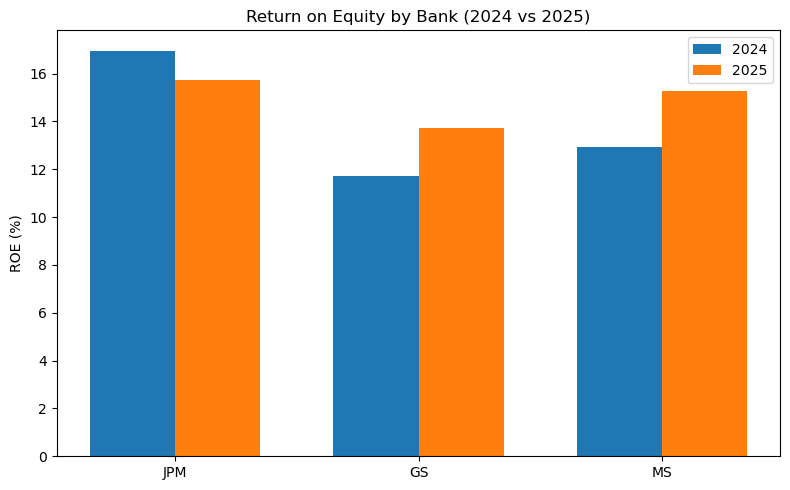

In [28]:
import matplotlib.pyplot as plt
import numpy as np

years = ["2024", "2025"]
x = np.arange(len(tickers))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

roe_2024 = combined[combined["year"] == "2024"]["ROE"].values * 100
roe_2025 = combined[combined["year"] == "2025"]["ROE"].values * 100

ax.bar(x - width / 2, roe_2024, width, label="2024")
ax.bar(x + width / 2, roe_2025, width, label="2025")

ax.set_ylabel("ROE (%)")
ax.set_title("Return on Equity by Bank (2024 vs 2025)")
ax.set_xticks(x)
ax.set_xticklabels(tickers)
ax.legend()

plt.tight_layout()
plt.savefig("roe_comparison.png", dpi=150)
plt.show()


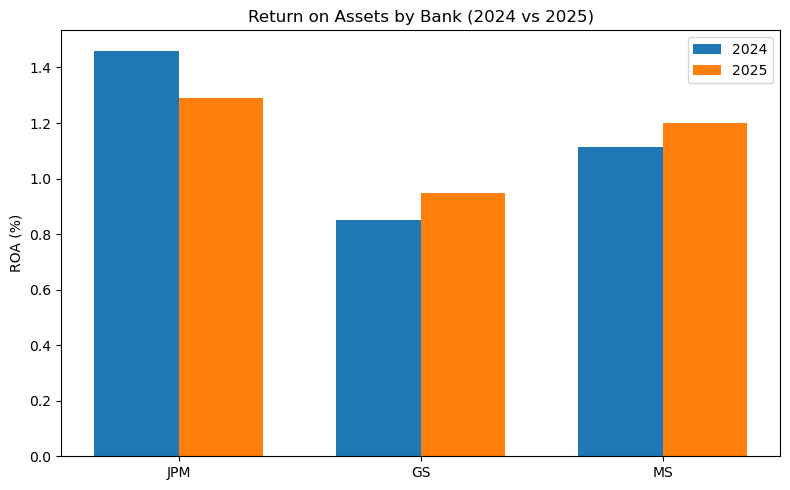

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))

roa_2024 = combined[combined["year"] == "2024"]["ROA"].values * 100
roa_2025 = combined[combined["year"] == "2025"]["ROA"].values * 100

ax.bar(x - width / 2, roa_2024, width, label="2024")
ax.bar(x + width / 2, roa_2025, width, label="2025")

ax.set_ylabel("ROA (%)")
ax.set_title("Return on Assets by Bank (2024 vs 2025)")
ax.set_xticks(x)
ax.set_xticklabels(tickers)
ax.legend()

plt.tight_layout()
plt.savefig("roa_comparison.png", dpi=150)
plt.show()


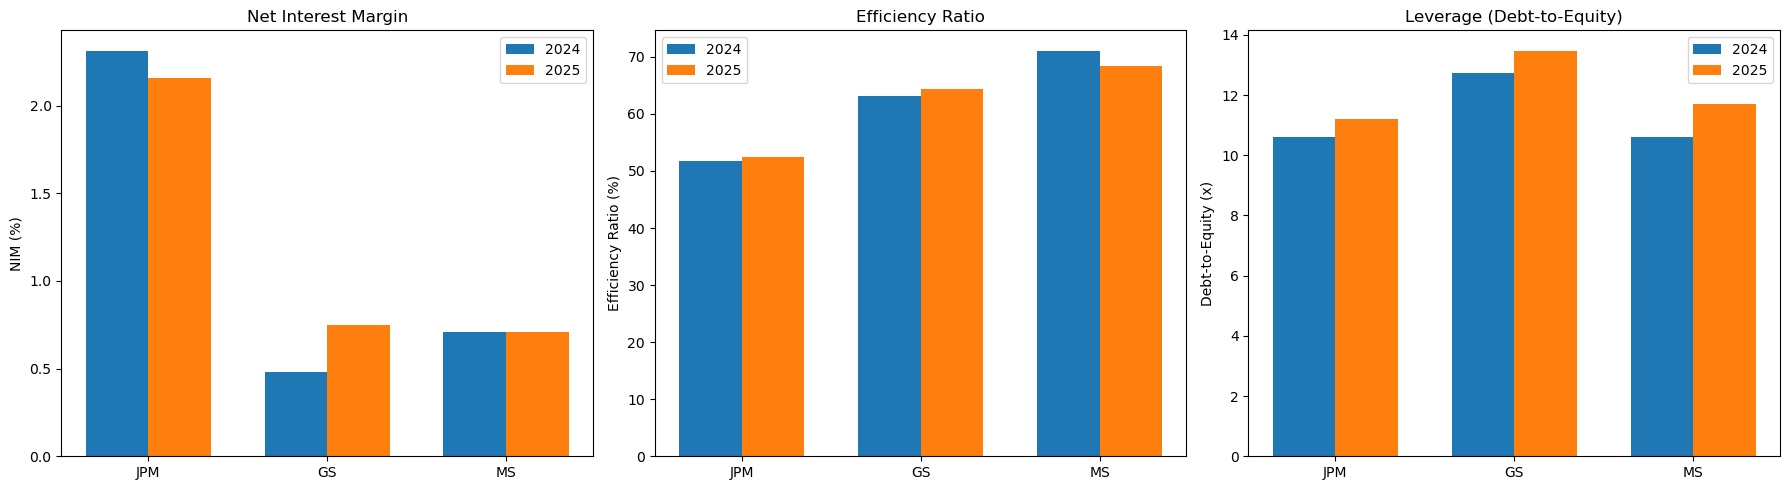

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# NIM
nim_2024 = combined[combined["year"] == "2024"]["NIM"].values * 100
nim_2025 = combined[combined["year"] == "2025"]["NIM"].values * 100
axes[0].bar(x - width / 2, nim_2024, width, label="2024")
axes[0].bar(x + width / 2, nim_2025, width, label="2025")
axes[0].set_ylabel("NIM (%)")
axes[0].set_title("Net Interest Margin")
axes[0].set_xticks(x)
axes[0].set_xticklabels(tickers)
axes[0].legend()

# Efficiency Ratio
er_2024 = combined[combined["year"] == "2024"]["Efficiency Ratio"].values * 100
er_2025 = combined[combined["year"] == "2025"]["Efficiency Ratio"].values * 100
axes[1].bar(x - width / 2, er_2024, width, label="2024")
axes[1].bar(x + width / 2, er_2025, width, label="2025")
axes[1].set_ylabel("Efficiency Ratio (%)")
axes[1].set_title("Efficiency Ratio")
axes[1].set_xticks(x)
axes[1].set_xticklabels(tickers)
axes[1].legend()

# Debt-to-Equity
dte_2024 = combined[combined["year"] == "2024"]["Debt-to-Equity"].values
dte_2025 = combined[combined["year"] == "2025"]["Debt-to-Equity"].values
axes[2].bar(x - width / 2, dte_2024, width, label="2024")
axes[2].bar(x + width / 2, dte_2025, width, label="2025")
axes[2].set_ylabel("Debt-to-Equity (x)")
axes[2].set_title("Leverage (Debt-to-Equity)")
axes[2].set_xticks(x)
axes[2].set_xticklabels(tickers)
axes[2].legend()

plt.tight_layout()
plt.savefig("nim_efficiency_leverage.png", dpi=150)
plt.show()


## Cross-bank comparison: JPMorgan, Goldman Sachs, Morgan Stanley (2024–2025)

### Methodology
All five ratios calculated in Days 3–5 (ROE, ROA, NIM, Efficiency Ratio, Debt-to-Equity) were combined into a single table, joined on ticker and year, then visualized as grouped bar charts to compare all three banks side by side across both years.

### Combined ratio table

| Ticker | Year | ROE | ROA | NIM | Efficiency Ratio | Debt-to-Equity |
|--------|------|-----|-----|-----|-------------------|-----------------|
| JPM | 2024 | 16.96% | 1.46% | 2.31% | 51.70% | 10.61x |
| JPM | 2025 | 15.74% | 1.29% | 2.16% | 52.42% | 11.21x |
| GS  | 2024 | 11.70% | 0.85% | 0.48% | 63.10% | 12.74x |
| GS  | 2025 | 13.74% | 0.95% | 0.75% | 64.42% | 13.48x |
| MS  | 2024 | 12.95% | 1.11% | 0.71% | 71.08% | 10.62x |
| MS  | 2025 | 15.25% | 1.20% | 0.71% | 68.43% | 11.71x |

### How the ratios connect

NIM and Efficiency Ratio together explain ROA: a bank with a strong core lending spread (high NIM) and a lean cost structure (low Efficiency Ratio) generates more profit per dollar of assets. Debt-to-Equity then amplifies ROA into ROE — since most of a bank's assets are funded by deposits and other liabilities rather than shareholder equity, even a modest ROA translates into a much larger return specifically for shareholders. This is why ROE is consistently several times larger than ROA across all three banks: leverage is doing the amplifying.

### Observations across all five ratios

- **JPM leads on the fundamentals that drive ROA** — highest NIM (2.16–2.31%) and lowest Efficiency Ratio (51.7–52.4%) of the three banks — and this shows up directly in JPM having the highest ROA both years.
- **GS compensates for weaker core fundamentals (lowest NIM, highest Efficiency Ratio) with the highest leverage** (12.7x–13.5x), which helps close the gap and deliver a competitive ROE despite a comparatively weak ROA.
- **MS sits in the middle on most metrics**, but stands out for improving Efficiency Ratio year over year (71.08% → 68.43%) while keeping leverage relatively stable — its ROE gain (12.95% → 15.25%) appears driven more by cost discipline than by increased leverage, unlike GS.
- **All three banks increased leverage slightly from 2024 to 2025**, and ROE moved differently for each: JPM's declined slightly (weaker underlying ROA outweighed the leverage increase), while GS and MS both improved (stronger ROA and/or efficiency gains outweighed the leverage increase).

## Day 7: Written analysis by bank

### JPMorgan Chase (JPM)
JPMorgan is the strongest of the three banks on almost every core profitability measure. Its Net Interest Margin sits well above Goldman Sachs and Morgan Stanley, at around 2.2 percent, because JPM runs a large traditional banking business built on deposits and lending, unlike its peers who lean more on trading and advisory work. It also runs the lowest Efficiency Ratio of the group, meaning it spends less to generate each dollar of revenue than either competitor. Together, this strong lending margin and lean cost base give JPM the highest Return on Assets of the three banks. However, both ROE and ROA slipped slightly from 2024 to 2025. This was mainly because JPM set aside significantly more money for potential loan losses that year, which reduced net income even though total revenue kept growing. JPM also runs the lowest leverage of the three banks, meaning its strong returns come more from the underlying business itself rather than from borrowing heavily to boost results, which points to a lower risk profile than its peers.

### Goldman Sachs (GS)
Goldman Sachs improved across nearly every ratio from 2024 to 2025. Its Net Interest Margin grew significantly, its Return on Assets rose, and its Return on Equity climbed from around 11.7 percent to nearly 13.75 percent. At the same time, its Efficiency Ratio also got worse, meaning it became more expensive for the bank to generate each dollar of revenue, which is a genuine downside sitting alongside the improvements. What really stands out about Goldman Sachs is that it carries the highest leverage of the three banks, and that leverage increased further in 2025. Because Goldman's core lending margin is much lower than JPMorgan's, and its costs are higher, leverage is doing a lot of the work in pushing its ROE up to a level that is competitive with its peers, even though its underlying asset returns are the weakest of the three banks.

### Morgan Stanley (MS)
Morgan Stanley sits between the other two banks on most measures, but its clearest story is about cost discipline. Its Efficiency Ratio actually improved from 2024 to 2025, dropping from around 71 percent to about 68 percent, even though it remains the least efficient of the three banks overall. Its Net Interest Margin stayed roughly flat year over year, so the improvement in its Return on Equity, which rose from about 13 percent to over 15 percent, appears to be driven mainly by better cost control rather than a stronger lending business or a big jump in leverage. Morgan Stanley's leverage did rise slightly but not nearly as much as Goldman Sachs, which suggests its improved returns are coming from genuinely running the business better rather than simply taking on more risk.

### Overall takeaway

Comparing all three banks together, a clear pattern emerges: strong profitability can come from two very different places. JPMorgan earns its returns through genuine operating strength, a high lending margin and a lean cost base, while running the least leverage of the three. Goldman Sachs, by contrast, has the weakest core lending economics and the highest costs, but closes much of the gap by running the most leverage, meaning more of its shareholder return is coming from financial structure rather than the underlying business. Morgan Stanley's improvement over the year came mainly from tightening costs rather than a stronger core business or added leverage, making it the most balanced of the three in terms of how its returns improved. This reinforces a broader point about bank analysis: ROE alone does not tell the full story, and two banks can arrive at a similar headline number through very different underlying paths.